# Computer Exercise 15.34 — Problem 2
## 결론 (C) 는 모멘트 선택에 불변인가 — $\bar\sigma$ 고정과 $\sqrt{\overline{\sigma^2}}$ 고정을 같은 시드에서

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 Ch 15
> **단원**: §15.34 Sequential Decision Making — Moment-Invariance of an Intervention
> **선행**: §15.32 (Day 99) · §15.33 P3 (Day 100)
> **풀이 일자**: Day 101 · **언어**: Python (NumPy / pandas / Matplotlib / SciPy)

Day 100 P3 은 잡음 스케일 $\sigma$ 의 **평균을 고정**하고 배분만 바꿔서 결론 (C) 를 얻었다 —
*크기를 고정하면 균일 · 무작위 · 학습된 세 배분이 구별되지 않는다*. 그런데 그 README 의
정직성 노트가 스스로 남긴 구멍이 있다:

> "평균 고정 제약은 두 모멘트 중 하나만 고정한다. (…) 이질적 arm 의 rms 가 $0.72$ 로 균일
> arm 의 $0.55$ 보다 큼에도 성능이 같다는 것은 추가 정보이지, 결론 (C) 를 위협하지 않는다.
> 다만 $\sqrt{\overline{\sigma^2}}$ 고정 하에서의 확인이 Day 101 (b) 에 예약되어 있다."

두 제약은 교란 에너지를 **반대 방향으로** 흘린다. $\mathrm{cv} > 0$ 인 arm 은
평균 고정 아래에서 rms 가 **크고**, rms 고정 아래에서 평균이 **작다**. 결론 (C) 가 두 제약
모두에서 유지되면 (C) 는 모멘트 선택에 **불변**이고, 한쪽에서만 유지되면 (C) 는 결론이
아니라 **제약의 부작용**이었다.

## 1. 문제 (원문)

> **Computer Exercise 15.34.2.** Exercise 15.33.3 held the *mean* of the exploration-noise scale
> vector $\sigma \in \mathbb{R}^d$ fixed and found that uniform, random and learned allocations of
> the remaining degrees of freedom were statistically indistinguishable. Since
> $\overline{\sigma^2} = \bar\sigma^{\,2}(1 + \mathrm{cv}^2)$, a mean-preserving projection *raises*
> the total perturbation energy of any heterogeneous arm, and an rms-preserving projection
> *lowers* its mean. The two constraints therefore bracket the confound.
>
> Repeat the comparison with $\sqrt{\overline{\sigma^2}}$ held fixed instead, running **both**
> constraints on the *same* seed pool so that the two are compared inside one implementation.
> Verify each intervention by assertion. Pre-register a family of size four, use a sign-flip
> permutation test with Holm correction, include an A/A check and a scale reference
> (a comparison whose effect is known to be large), and report $n^\star$ for every
> non-significant cell. State whether conclusion (C) is invariant to the choice of moment.

### 한국어 풀이용 정리

1. **두 제약을 같은 40 시드에서 나란히** 돌린다 (Day 100 의 값과 대조하는 것이 아니라,
   **한 구현 안에서** 비교한다 — 재구성 계열이 다르면 절대값을 비교할 수 없기 때문).
2. **제약 성립을 assert 로 확인** — rms 고정 arm 의 $\sqrt{\overline{\sigma^2}}$ 가 목표와
   기계 정밀도 내에서 일치하고, 무작위 배분과 학습된 배분의 $\mathrm{cv}$ 가 일치하는가.
3. **사전 명시 가족 $m=4$** — rms 고정 아래 세 배분의 세 쌍 비교 + 크기 효과 (축척 기준).
4. **2 차 (보정 없음)** — 같은 시드에서의 평균 고정 재현. Day 100 P3 이 재현되는가.
5. **판정** — sign-flip + Holm + 검정 반전 CI, 비유의 셀마다 $n^\star$.

## 2. 수학적 배경

### 2.1 두 사영은 같은 방향의 제약이 아니다

$\sigma \in \mathbb{R}^d_{>0}$, $\bar\sigma = d^{-1}\sum_i \sigma_i$, $\mathrm{rms}(\sigma) = \sqrt{d^{-1}\sum_i \sigma_i^2}$,
$\mathrm{cv} = \mathrm{sd}(\sigma)/\bar\sigma$ 라 하자. 항등식

$$\boxed{\;\mathrm{rms}(\sigma)^2 \;=\; \bar\sigma^{\,2}\,\bigl(1 + \mathrm{cv}^2\bigr)\;}$$

에서, 목표값 $c$ 에 대한 두 사영은

$$\Pi_{\text{mean}}(\sigma) = \frac{c}{\bar\sigma}\,\sigma
\quad\Longrightarrow\quad \mathrm{rms} = c\sqrt{1+\mathrm{cv}^2} \;\ge\; c,$$
$$\Pi_{\text{rms}}(\sigma) = \frac{c}{\mathrm{rms}(\sigma)}\,\sigma
\quad\Longrightarrow\quad \bar\sigma = \frac{c}{\sqrt{1+\mathrm{cv}^2}} \;\le\; c.$$

두 사영 모두 $\sigma$ 의 **방향** (배분) 을 보존하고 크기만 바꾼다. 따라서 배분 효과를 재는
설계로서 둘 다 정당하지만, 이질적 arm 에 남기는 **총 교란 에너지가 정반대**다.
Day 100 P3 의 실측 $\mathrm{cv} = 0.8398$ 을 넣으면 $\sqrt{1+\mathrm{cv}^2} = 1.307$ 이므로,
같은 배분이 평균 고정에서는 rms $0.719$ 를, rms 고정에서는 평균 $0.421$ 을 갖는다.

### 2.2 왜 이것이 결론을 위협할 수 있는가

Day 100 P3 의 결론 (C) 는 "배분 무관" 이었다. 그러나 평균 고정 설계에서 이질적 arm 은
에너지를 **더** 받고도 이기지 못했다. 이는 두 가지로 읽힌다.

* **(C-불변)** 배분은 정말 무관하고, 여분의 에너지도 도움이 안 된다. → rms 고정에서
  이질적 arm 의 평균이 **줄어도** 여전히 붙어야 한다 (크기 효과가 그 구간에서 평평하므로).
* **(C-부작용)** 배분은 해롭고 여분 에너지가 그 손해를 정확히 상쇄했다. → rms 고정에서는
  상쇄가 사라져 이질적 arm 이 **진다**.

두 예측이 다르므로 실험으로 가릴 수 있다. 이것이 오늘의 사전 예측이다.

### 2.3 좌표 치환은 모든 모멘트를 보존한다

배분 효과를 재는 가장 깨끗한 방법은 사영이 아니라 **치환**이다. $\pi$ 를 좌표의 순열이라 하면
$\sigma_{\pi}$ 는 $\sigma$ 와 **같은 다중집합**을 가지므로

$$\boxed{\;\overline{\sigma_\pi^{\,k}} = \overline{\sigma^{\,k}} \quad \forall k, \qquad
\bar\sigma_\pi = \bar\sigma, \quad \mathrm{rms}(\sigma_\pi) = \mathrm{rms}(\sigma), \quad
\mathrm{cv}(\sigma_\pi) = \mathrm{cv}(\sigma).\;}$$

따라서 학습된 $\sigma$ 와 그것을 치환한 $\sigma_\pi$ 를 비교하면 **크기·이질성·분포 모양이
모두 동일**하고 오직 *어느 좌표가 어느 값을 받는가* 만 다르다. 이것이 "배분" 의 가장 좁은
정의이며, 1 차 가족의 첫 비교 $e_1$ 이 그것이다. (P3 의 $g_2$ 가 시간 축에서 하는 역할을
$e_1$ 이 좌표 축에서 한다.)

### 2.4 판정 규칙

P1 과 동일 — 짝지은 차에 부호뒤집기 순열검정 ($B = 20000$), 가족 $m=4$ 에 Holm,
구간은 검정 반전 CI, 비유의 셀에는 $n^\star = (2.8 s/|\bar d|)^2$. 비유의는 **판정불능**으로 읽고
"차이 없음" 으로 읽지 않는다.

## 3. 풀이 흐름

1. **공통 설정** — Day 99–100 계열의 5-상태 chain MDP (미끼 $0.25$), 트렁크 MLP + Factorized
   Noisy 헤드, **평균 사영**과 **rms 사영** 두 제약을 모두 구현.
2. **사전 명시** — 가설·가족·규칙·$n$·중지 규칙을 자료 생성 전에 못박는다.
3. **[1] 학습 arm** — 자유 `cnrt` 와 두 제약 학습 `cnrt_rc` (rms 사영) · `cnrt_mc` (mean 사영).
4. **[2] 배분 패턴 구성** — **제약 아래에서 학습된** $\sigma$ 를 좌표 치환한다. 치환은 모든
   모멘트를 보존하므로 (§2.3) 재정규화가 필요 없고, 짝이 되는 학습 arm 과 $\bar\sigma$ ·
   rms · cv 가 **정확히** 일치한다.
5. **[3] 나머지 arm 학습·배포** — `base`, `fix_small`, `fix_big` (균일; 두 제약의 공통 기준점),
   `het_rms` / `het_mean`.
6. **[4] 개입 검증** — 목표 모멘트가 정확히 걸렸는지, $\mathrm{cv}$ 가 짝지어졌는지 assert.
7. **[5] A/A 점검** — 프로토콜 v2 필수.
8. **[6] 판정** — 1 차 가족 $m=4$ + Holm, 2 차로 평균 고정 재현.
9. **[7]–[9] 시각화와 요약** — 모멘트 평면, forest plot, 판정표.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
from scipy.stats import norm

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 (Day 99–100 과 동일 계열의 재구성) ───────────────────────────
NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL, SIGMA0 = 0.95, 0.05, 16, 0.25, 0.5
SIG_INIT = SIGMA0 / np.sqrt(H)      # 0.125
SIG_T    = 0.55                     # 목표 모멘트 (Day 99 P2 의 fix_big 값)

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    return s2, (1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0))

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

ARM_SPEC = {"base": (False, False, False), "cnrt": (True, True, True),
            "fixed": (True, False, True)}

class Learner:
    """Trunk MLP (tanh, H=16) + linear head.  Noisy 헤드는 (mu, sigma) 로 분해."""
    def __init__(self, rng, arm="base", sigma_init=None, sigma_pattern=None,
                 target=None, moment=None):
        self.arm = arm; self.h = H
        sigma_init = SIG_INIT if sigma_init is None else sigma_init
        self.explore_noise, self.learn_sigma, self.inject = ARM_SPEC[arm]
        self.target, self.moment, self.scale = target, moment, 1.0
        self.W1 = rng.normal(0, 0.3, (H, NS)); self.b1 = np.zeros(H)
        self.W2 = rng.normal(0, 0.3, (NA, H)); self.b2 = np.zeros(NA)
        self.Ws = np.full((NA, H), sigma_init); self.bs = np.full(NA, sigma_init)
        if sigma_pattern is not None:
            self.Ws = sigma_pattern[0].copy(); self.bs = sigma_pattern[1].copy()
        self.eps_W = np.zeros((NA, H)); self.eps_b = np.zeros(NA)
    def sflat(self):      return np.concatenate([self.Ws.ravel(), self.bs.ravel()])
    def sigma_mean(self): return float(self.sflat().mean())
    def sigma_rms(self):  return float(np.sqrt((self.sflat() ** 2).mean()))
    def sigma_cv(self):
        f = self.sflat(); return float(f.std() / f.mean())
    def project(self):
        """지정된 모멘트를 목표값으로 사영 (§2.1). 방향=배분은 보존된다."""
        if self.target is None: return
        cur = self.sigma_mean() if self.moment == "mean" else self.sigma_rms()
        if cur > 1e-12:
            r = self.target / cur; self.Ws *= r; self.bs *= r
    def resample(self, rng):
        if not self.inject: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo
    def q(self, s, noise=False):
        a1 = np.tanh(self.W1 @ onehot(s) + self.b1)
        use = noise and self.inject
        W = self.W2 + (self.Ws * self.scale * self.eps_W if use else 0.0)
        b = self.b2 + (self.bs * self.scale * self.eps_b if use else 0.0)
        return W @ a1 + b, a1
    def update(self, s, a, target):
        qv, a1 = self.q(s, noise=False); d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        gz = (d * self.W2[a]) * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.learn_sigma:
            self.Ws -= ETA * gW2 * self.eps_W * self.scale
            self.bs -= ETA * gb2 * self.eps_b * self.scale
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)
            self.project()

def train(seed, T, arm="base", p_train=0.20, eps_greedy=0.10, sigma_init=None,
          sigma_pattern=None, target=None, moment=None, trace_every=None):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, arm=arm, sigma_init=sigma_init, sigma_pattern=sigma_pattern,
                 target=target, moment=moment)
    lr.trace = []; s = 0
    for t in range(T):
        if t % L == 0: s = 0; lr.resample(rng)
        if lr.explore_noise:
            a = int(np.argmax(lr.q(s, noise=True)[0]))
        else:
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(lr.q(s)[0]))
        s2, r = step(s, a, p_train, rng)
        lr.update(s, a, r + GAMMA * float(np.max(lr.q(s2)[0])))
        s = s2
        if trace_every and t % trace_every == 0:
            lr.trace.append((t, lr.sigma_mean(), lr.sigma_rms()))
    return lr

def greedy_policy(lr): return tuple(int(np.argmax(lr.q(s)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    rng = np.random.default_rng(seed); pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

T_FIXED, P_DEPLOY, N_EP = 10_000, 0.20, 40
ALPHA, B_MAIN = 0.05, 20_000

# ── 판정 규칙 (프로토콜 v2, Day 100 P1 에서 채택) ─────────────────────────
def signflip_p(d, B=B_MAIN, seed=1, rng=None):
    rng = np.random.default_rng(seed) if rng is None else rng
    d = np.asarray(d, float); obs = abs(d.mean())
    null = np.abs((rng.choice([-1.0, 1.0], size=(B, len(d))) * d).mean(axis=1))
    return float((1 + (null >= obs - 1e-15).sum()) / (B + 1))

def holm(pv, alpha=ALPHA):
    p = np.asarray(pv, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * p[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

_CI = {}
def invert_ci(d, B=3000, seed=7, alpha=ALPHA, it=22):
    d = np.asarray(d, float); key = (d.tobytes(), B, seed)
    if key in _CI: return _CI[key]
    c = d.mean()
    ok = lambda x: signflip_p(d - x, B=B, seed=seed) > alpha
    if not ok(c): _CI[key] = (np.nan, np.nan); return _CI[key]
    a, b = c, c + 2.0
    for _ in range(it):
        m = .5*(a+b); a, b = (m, b) if ok(m) else (a, m)
    up = .5*(a+b)
    a, b = c - 2.0, c
    for _ in range(it):
        m = .5*(a+b); a, b = (a, m) if ok(m) else (m, b)
    _CI[key] = (.5*(a+b), up); return _CI[key]

def n_star(d, c=2.8):
    d = np.asarray(d, float); m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((c*s/m)**2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    p = k/n; den = 1 + z*z/n; ctr = (p + z*z/(2*n))/den
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/den
    return (max(0., ctr-hw), min(1., ctr+hw))

print(f"chain MDP  states={NS} actions={NA} ep_len={L} gamma={GAMMA} 미끼={R_LOCAL}")
print(f"sigma 초기 {SIG_INIT:.4f} · 목표 모멘트 {SIG_T} · 두 사영 = mean / rms")
print("판정 규칙: sign-flip + Holm + 검정 반전 CI  [프로토콜 v2]")

chain MDP  states=5 actions=2 ep_len=20 gamma=0.95 미끼=0.25
sigma 초기 0.1250 · 목표 모멘트 0.55 · 두 사영 = mean / rms
판정 규칙: sign-flip + Holm + 검정 반전 CI  [프로토콜 v2]


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [사전 명시 — PRE-REGISTRATION]   자료 생성 전에 실행
# ══════════════════════════════════════════════════════════════════════════
PRE = {
 "질문": "Day 100 P3 의 결론 (C)('크기를 고정하면 배분은 무관') 는 고정하는 모멘트에 불변인가",
 "개입": "sigma <- sigma * 0.55 / rms(sigma)   (Day 100 은 mean 사영을 썼다)",
 "1차 가족 (m=4, 순서 고정)": [
   "e1 = het_rms  - cnrt_rc ★ <- 치환 대 학습된 배분: 다중집합이 동일, 좌표 배치만 다름",
   "e2 = fix_big  - cnrt_rc   <- 균일 대 학습된 배분   (rms 고정)",
   "e3 = fix_big  - het_rms   <- 균일 대 치환된 배분   (rms 고정)",
   "e4 = fix_big  - fix_small <- 크기 효과 (배분 동일; 축척 기준 = 알려진 큰 효과)",
 ],
 "1차 판정 규칙": "부호뒤집기 순열검정 B=20000, alpha=0.05, Holm(m=4), 검정 반전 CI",
 "표본 크기": "n=40 신규 독립 시드 101201-101240 (v2 최소 30 초과, Day 100 과 비중첩)",
 "2차 (보정 없음)": "같은 40 시드에서 mean 고정 3 비교 = Day 100 P3 재현",
 "사전 예측": "(C-불변) 이면 e1,e2,e3 모두 비유의 / (C-부작용) 이면 e2>0 또는 e3>0 이 유의",
 "필수 점검": "제약 성립 assert (rms 편차 < 1e-12) + 치환 쌍의 mean·rms·cv 완전 일치 assert + A/A 점검",
 "중지 규칙": "n=40 을 다 쓰고 한 번만 판정한다.",
}
print("═"*78); print("PRE-REGISTRATION   (Day 101 §15.34 P2)"); print("═"*78)
for k, v in PRE.items():
    if isinstance(v, list): print(f"{k}:"); [print(f"    - {x}") for x in v]
    else: print(f"{k}: {v}")
print("═"*78)
SEEDS2 = list(range(101201, 101241)); N2 = len(SEEDS2)
print(f"판정 풀 n={N2}  (101201-101240)")

══════════════════════════════════════════════════════════════════════════════
PRE-REGISTRATION   (Day 101 §15.34 P2)
══════════════════════════════════════════════════════════════════════════════
질문: Day 100 P3 의 결론 (C)('크기를 고정하면 배분은 무관') 는 고정하는 모멘트에 불변인가
개입: sigma <- sigma * 0.55 / rms(sigma)   (Day 100 은 mean 사영을 썼다)
1차 가족 (m=4, 순서 고정):
    - e1 = het_rms  - cnrt_rc ★ <- 치환 대 학습된 배분: 다중집합이 동일, 좌표 배치만 다름
    - e2 = fix_big  - cnrt_rc   <- 균일 대 학습된 배분   (rms 고정)
    - e3 = fix_big  - het_rms   <- 균일 대 치환된 배분   (rms 고정)
    - e4 = fix_big  - fix_small <- 크기 효과 (배분 동일; 축척 기준 = 알려진 큰 효과)
1차 판정 규칙: 부호뒤집기 순열검정 B=20000, alpha=0.05, Holm(m=4), 검정 반전 CI
표본 크기: n=40 신규 독립 시드 101201-101240 (v2 최소 30 초과, Day 100 과 비중첩)
2차 (보정 없음): 같은 40 시드에서 mean 고정 3 비교 = Day 100 P3 재현
사전 예측: (C-불변) 이면 e1,e2,e3 모두 비유의 / (C-부작용) 이면 e2>0 또는 e3>0 이 유의
필수 점검: 제약 성립 assert (rms 편차 < 1e-12) + 치환 쌍의 mean·rms·cv 완전 일치 assert + A/A 점검
중지 규칙: n=40 을 다 쓰고 한 번만 판정한다.
════════════════════════════════════════════════════════

In [3]:
# ── [1] 학습 arm 3 종 (자유 / rms 사영 / mean 사영) ──────────────────────
t0 = time.time()
LS = {}
LS["cnrt"]    = [train(s, T_FIXED, arm="cnrt", trace_every=250) for s in SEEDS2]
LS["cnrt_rc"] = [train(s, T_FIXED, arm="cnrt", sigma_init=SIG_T, target=SIG_T,
                       moment="rms",  trace_every=250) for s in SEEDS2]
LS["cnrt_mc"] = [train(s, T_FIXED, arm="cnrt", sigma_init=SIG_T, target=SIG_T,
                       moment="mean", trace_every=250) for s in SEEDS2]
print(f"학습 arm 3 종 x {N2} 시드  ({time.time()-t0:.1f} s)\n")
for nm in ["cnrt", "cnrt_rc", "cnrt_mc"]:
    mm = np.array([l.sigma_mean() for l in LS[nm]]); rr = np.array([l.sigma_rms() for l in LS[nm]])
    cc = np.array([l.sigma_cv()   for l in LS[nm]])
    print(f"  {nm:8s} 종료 sigma : mean={mm.mean():.4f}  rms={rr.mean():.4f}  cv={cc.mean():.4f}"
          f"   (항등식 잔차 {np.abs(rr - mm*np.sqrt(1+cc**2)).max():.1e})")

학습 arm 3 종 x 40 시드  (57.4 s)

  cnrt     종료 sigma : mean=0.5521  rms=0.7226  cv=0.8591   (항등식 잔차 2.2e-16)
  cnrt_rc  종료 sigma : mean=0.3663  rms=0.5500  cv=1.1335   (항등식 잔차 1.1e-16)
  cnrt_mc  종료 sigma : mean=0.5500  rms=0.7301  cv=0.8694   (항등식 잔차 2.2e-16)


In [4]:
# ── [2] 배분 패턴 구성 (좌표 치환 + 두 모멘트로 재정규화) ────────────────
def permute(lr, seed):
    """제약 아래 학습된 sigma 를 좌표에 대해 치환.  §2.3 -> 모든 모멘트가 보존되므로
    재정규화가 필요 없다.  짝이 되는 학습 arm 과 다중집합이 완전히 같다."""
    rng = np.random.default_rng(600_000 + seed)
    flat = rng.permutation(lr.sflat()); nW = lr.Ws.size
    return flat[:nW].reshape(lr.Ws.shape), flat[nW:].reshape(lr.bs.shape)

PAT_RMS  = {s: permute(l, s) for s, l in zip(SEEDS2, LS["cnrt_rc"])}
PAT_MEAN = {s: permute(l, s) for s, l in zip(SEEDS2, LS["cnrt_mc"])}
chk = []
for s, l in zip(SEEDS2, LS["cnrt_rc"]):
    a = l.sflat(); b = np.concatenate([PAT_RMS[s][0].ravel(), PAT_RMS[s][1].ravel()])
    chk.append([abs(a.mean()-b.mean()), abs(np.sqrt((a**2).mean())-np.sqrt((b**2).mean())),
                float(np.abs(np.sort(a)-np.sort(b)).max())])
chk = np.array(chk)
assert chk.max() < 1e-12, f"치환이 모멘트를 보존하지 않았다: {chk.max():.2e}"
print("배분 패턴 = 제약 학습 arm 의 좌표 치환 (재정규화 없음)")
print(f"  치환 쌍의 |Δmean| 최대 {chk[:,0].max():.2e} · |Δrms| 최대 {chk[:,1].max():.2e}"
      f" · 정렬값 최대 차 {chk[:,2].max():.2e}")
print("  -> het_rms 와 cnrt_rc 는 sigma 의 다중집합이 완전히 같고 좌표 배치만 다르다 (§2.3)")

배분 패턴 = 제약 학습 arm 의 좌표 치환 (재정규화 없음)
  치환 쌍의 |Δmean| 최대 1.11e-16 · |Δrms| 최대 1.11e-16 · 정렬값 최대 차 0.00e+00
  -> het_rms 와 cnrt_rc 는 sigma 의 다중집합이 완전히 같고 좌표 배치만 다르다 (§2.3)


In [5]:
# ── [3] 8 개 arm 학습·배포 ────────────────────────────────────────────────
t0 = time.time()
LS["base"]      = [train(s, T_FIXED, arm="base") for s in SEEDS2]
LS["fix_small"] = [train(s, T_FIXED, arm="fixed", sigma_init=SIG_INIT) for s in SEEDS2]
LS["fix_big"]   = [train(s, T_FIXED, arm="fixed", sigma_init=SIG_T) for s in SEEDS2]
LS["het_rms"]   = [train(s, T_FIXED, arm="fixed", sigma_pattern=PAT_RMS[s]) for s in SEEDS2]
LS["het_mean"]  = [train(s, T_FIXED, arm="fixed", sigma_pattern=PAT_MEAN[s]) for s in SEEDS2]
ORDER = ["base", "fix_small", "fix_big", "het_rms", "cnrt_rc", "het_mean", "cnrt_mc", "cnrt"]
R2 = {nm: np.array([deploy(l, P_DEPLOY, N_EP, 830_000 + i) for i, l in enumerate(LS[nm])])
      for nm in ORDER}
print(f"나머지 5 arm x {N2} 시드 x T={T_FIXED}  ({time.time()-t0:.1f} s) — 총 8 arm")
print(pd.DataFrame([{"arm": nm, "R_mean": R2[nm].mean(), "R_sd": R2[nm].std(ddof=1)}
                    for nm in ORDER]).to_string(index=False))

나머지 5 arm x 40 시드 x T=10000  (59.8 s) — 총 8 arm
      arm  R_mean   R_sd
     base  0.5575 0.0845
fix_small  0.4071 0.1993
  fix_big  0.5663 0.0863
  het_rms  0.5689 0.0814
  cnrt_rc  0.5646 0.0826
 het_mean  0.5707 0.0568
  cnrt_mc  0.5710 0.0580
     cnrt  0.4671 0.1766


In [6]:
# ── [4] 개입 검증: 제약이 실제로 걸렸는가 ────────────────────────────────
diag = []
for nm in ORDER:
    m = np.array([l.sigma_mean() for l in LS[nm]]); r = np.array([l.sigma_rms() for l in LS[nm]])
    c = np.array([l.sigma_cv()   for l in LS[nm]])
    diag.append({"arm": nm, "mean σ": m.mean(), "rms σ": r.mean(), "cv": c.mean(),
                 "rms 편차": np.abs(r - SIG_T).max(), "mean 편차": np.abs(m - SIG_T).max()})
diag_df = pd.DataFrame(diag)
print(diag_df.to_string(index=False))

dev_rms  = max(np.abs(np.array([l.sigma_rms()  for l in LS["cnrt_rc"]]) - SIG_T).max(),
               np.abs(np.array([l.sigma_rms()  for l in LS["het_rms"]]) - SIG_T).max(),
               np.abs(np.array([l.sigma_rms()  for l in LS["fix_big"]]) - SIG_T).max())
dev_mean = max(np.abs(np.array([l.sigma_mean() for l in LS["cnrt_mc"]]) - SIG_T).max(),
               np.abs(np.array([l.sigma_mean() for l in LS["het_mean"]]) - SIG_T).max())
assert dev_rms  < 1e-12, f"rms 사영 실패: {dev_rms:.2e}"
assert dev_mean < 1e-12, f"mean 사영 실패: {dev_mean:.2e}"
cv_r = np.array([l.sigma_cv() for l in LS["het_rms"]]); cv_c = np.array([l.sigma_cv() for l in LS["cnrt_rc"]])
print(f"\n✓ rms 사영 최대 편차 {dev_rms:.2e} · mean 사영 최대 편차 {dev_mean:.2e}")
print(f"✓ 치환 쌍 cv 완전 일치 : het_rms {cv_r.mean():.6f} 대 cnrt_rc {cv_c.mean():.6f} "
      f"(시드별 최대 차 {np.abs(cv_r-cv_c).max():.2e})")
print(f"✓ §2.1 예측 검증 : het_mean 의 rms = {diag_df.loc[diag_df.arm=='het_mean','rms σ'].item():.4f} "
      f"( > {SIG_T} ) · het_rms 의 mean = {diag_df.loc[diag_df.arm=='het_rms','mean σ'].item():.4f} "
      f"( < {SIG_T} )  -> 두 제약이 에너지를 반대로 흘린다")

      arm  mean σ  rms σ     cv  rms 편차  mean 편차
     base  0.1250 0.1250 0.0000  0.4250   0.4250
fix_small  0.1250 0.1250 0.0000  0.4250   0.4250
  fix_big  0.5500 0.5500 0.0000  0.0000   0.0000
  het_rms  0.3663 0.5500 1.1335  0.0000   0.2615
  cnrt_rc  0.3663 0.5500 1.1335  0.0000   0.2615
 het_mean  0.5500 0.7301 0.8694  0.2640   0.0000
  cnrt_mc  0.5500 0.7301 0.8694  0.2640   0.0000
     cnrt  0.5521 0.7226 0.8591  0.5492   0.4041

✓ rms 사영 최대 편차 1.11e-16 · mean 사영 최대 편차 2.22e-16
✓ 치환 쌍 cv 완전 일치 : het_rms 1.133528 대 cnrt_rc 1.133528 (시드별 최대 차 4.44e-16)
✓ §2.1 예측 검증 : het_mean 의 rms = 0.7301 ( > 0.55 ) · het_rms 의 mean = 0.3663 ( < 0.55 )  -> 두 제약이 에너지를 반대로 흘린다


In [7]:
# ── [5] A/A 점검 (프로토콜 v2 필수) ──────────────────────────────────────
M_AA, B_AA, N_AA = 500, 2000, 20
rng = np.random.default_rng(3141)
pool = R2["fix_big"] - R2["fix_big"].mean()      # 중심화된 실측 잔차
rej = 0
for _ in range(M_AA):
    a = rng.choice(pool, size=N_AA, replace=True); b = rng.choice(pool, size=N_AA, replace=True)
    rej += signflip_p(a - b, B=B_AA, rng=rng) <= ALPHA
rate = rej / M_AA; w = wilson(rej, M_AA)
print(f"A/A (재무작위화, M={M_AA}, n={N_AA}) 1종 오류 = {rate:.3f}  "
      f"Wilson 95% CI [{w[0]:.3f}, {w[1]:.3f}]  명목 {ALPHA}")
print("통과 — 규칙이 명목을 지킨다" if w[0] <= ALPHA <= w[1] else "경보 — 명목 이탈")

A/A (재무작위화, M=500, n=20) 1종 오류 = 0.046  Wilson 95% CI [0.031, 0.068]  명목 0.05
통과 — 규칙이 명목을 지킨다


In [8]:
# ── [6] 판정: 1차 가족 (m=4) + 2차 재현 ──────────────────────────────────
t0 = time.time()
FAM = [("e1  het_rms - cnrt_rc ★ (치환 대 학습; 다중집합 동일)", R2["het_rms"] - R2["cnrt_rc"]),
       ("e2  fix_big - cnrt_rc   (균일 대 학습, rms)",           R2["fix_big"] - R2["cnrt_rc"]),
       ("e3  fix_big - het_rms   (균일 대 치환, rms)",           R2["fix_big"] - R2["het_rms"]),
       ("e4  fix_big - fix_small (크기 효과, 축척 기준)",         R2["fix_big"] - R2["fix_small"])]
ps = [signflip_p(d, seed=300+i) for i, (_, d) in enumerate(FAM)]
adj, rej_ = holm(ps)
rows = []
for (nm, d), p, pa, rj in zip(FAM, ps, adj, rej_):
    lo, hi = invert_ci(d)
    rows.append({"비교": nm, "d": d.mean(), "sd": d.std(ddof=1), "CI_low": lo, "CI_high": hi,
                 "p": p, "p_Holm": pa, "기각": "★" if rj else "", "n*": n_star(d)})
fam_df = pd.DataFrame(rows)
print("1차 가족 (rms 고정)\n"); print(fam_df.to_string(index=False))

SEC = [("f1  het_mean - cnrt_mc (치환 대 학습, mean)", R2["het_mean"] - R2["cnrt_mc"]),
       ("f2  fix_big - cnrt_mc  (균일 대 학습, mean)",  R2["fix_big"] - R2["cnrt_mc"]),
       ("f3  fix_big - het_mean (균일 대 치환, mean)",  R2["fix_big"] - R2["het_mean"]),
       ("f4  cnrt_mc - cnrt     (평균 고정의 이득)",     R2["cnrt_mc"] - R2["cnrt"]),
       ("f5  cnrt_rc - cnrt     (rms 고정의 이득)",      R2["cnrt_rc"] - R2["cnrt"])]
sec_df = pd.DataFrame([{"비교": nm, "d": d.mean(), "p": signflip_p(d, seed=400+i),
                        "n*": n_star(d)} for i, (nm, d) in enumerate(SEC)])
print("\n2차 — Day 100 P3 재현 (평균 고정) 및 참고 비교 · Holm 보정 없음\n")
print(sec_df.to_string(index=False))
print(f"\n  ({time.time()-t0:.1f} s)")

1차 가족 (rms 고정)

                                        비교       d     sd  CI_low  CI_high      p  p_Holm 기각   n*
e1  het_rms - cnrt_rc ★ (치환 대 학습; 다중집합 동일)  0.0043 0.0829 -0.0201   0.0284 0.7535  1.0000    2875
    e2  fix_big - cnrt_rc   (균일 대 학습, rms)  0.0017 0.0212 -0.0033   0.0077 1.0000  1.0000    1285
    e3  fix_big - het_rms   (균일 대 치환, rms) -0.0027 0.0825 -0.0263   0.0213 0.8762  1.0000    7468
    e4  fix_big - fix_small (크기 효과, 축척 기준)  0.1592 0.2085  0.0922   0.2279 0.0001  0.0004  ★   14

2차 — Day 100 P3 재현 (평균 고정) 및 참고 비교 · Holm 보정 없음

                                    비교       d      p     n*
f1  het_mean - cnrt_mc (치환 대 학습, mean) -0.0003 0.9849 301232
f2  fix_big - cnrt_mc  (균일 대 학습, mean) -0.0047 0.8727   1795
f3  fix_big - het_mean (균일 대 치환, mean) -0.0045 0.7168   1554
    f4  cnrt_mc - cnrt     (평균 고정의 이득)  0.1038 0.0002     21
   f5  cnrt_rc - cnrt     (rms 고정의 이득)  0.0975 0.0013     26

  (0.1 s)


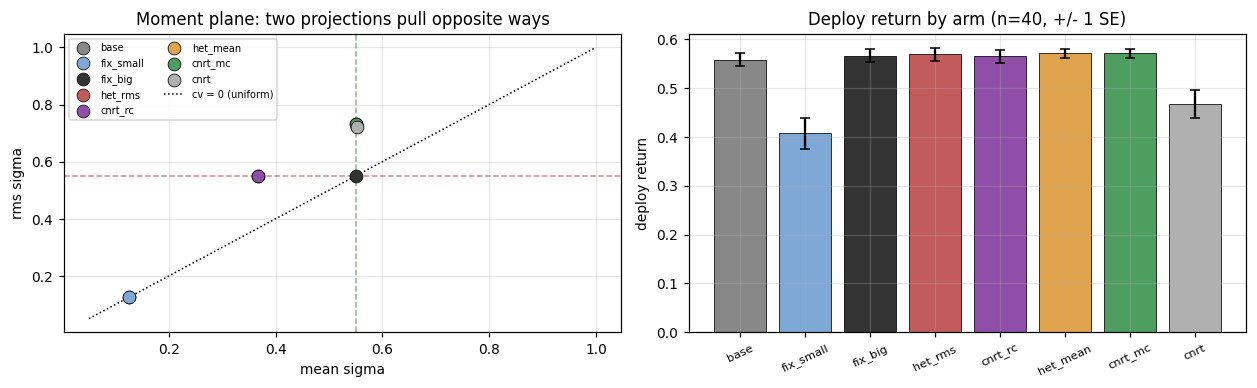

In [9]:
# ── [7] Fig 1 — 모멘트 평면과 arm 배치 ───────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
col = {"base": "#888", "fix_small": "#7fa8d6", "fix_big": "#333", "het_rms": "#c25b5b",
       "cnrt_rc": "#8f4fa8", "het_mean": "#e0a44f", "cnrt_mc": "#4d9e5f", "cnrt": "#b0b0b0"}
for nm in ORDER:
    m = np.mean([l.sigma_mean() for l in LS[nm]]); r = np.mean([l.sigma_rms() for l in LS[nm]])
    ax[0].scatter(m, r, s=70, color=col[nm], label=nm, zorder=3, edgecolor="k", linewidth=.5)
g = np.linspace(0.05, 1.0, 100)
ax[0].plot(g, g, "k:", lw=1, label="cv = 0 (uniform)")
ax[0].axvline(SIG_T, color="#4d9e5f", ls="--", lw=1, alpha=.7)
ax[0].axhline(SIG_T, color="#c25b5b", ls="--", lw=1, alpha=.7)
ax[0].set_xlabel("mean sigma"); ax[0].set_ylabel("rms sigma")
ax[0].set_title("Moment plane: two projections pull opposite ways")
ax[0].legend(fontsize=6.5, ncol=2)

x = np.arange(len(ORDER))
mu = [R2[nm].mean() for nm in ORDER]
se = [R2[nm].std(ddof=1)/np.sqrt(N2) for nm in ORDER]
ax[1].bar(x, mu, yerr=se, capsize=3, color=[col[n] for n in ORDER],
          edgecolor="k", linewidth=.5)
ax[1].set_xticks(x, ORDER, rotation=25, fontsize=7.5)
ax[1].set_ylabel("deploy return"); ax[1].set_title(f"Deploy return by arm (n={N2}, +/- 1 SE)")
plt.show()

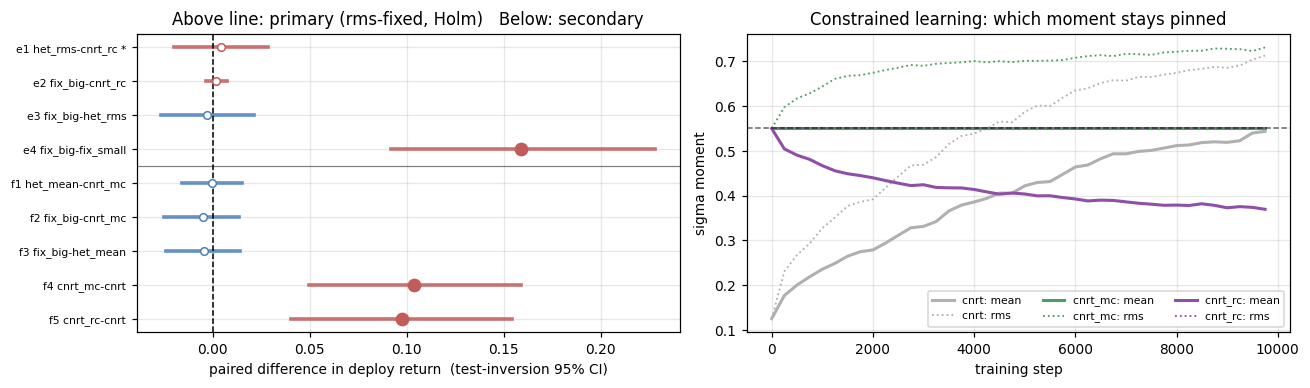

In [10]:
# ── [8] Fig 2 — forest plot (두 제약 병기) ───────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
lab = ["e1 het_rms-cnrt_rc *", "e2 fix_big-cnrt_rc", "e3 fix_big-het_rms",
       "e4 fix_big-fix_small", "f1 het_mean-cnrt_mc", "f2 fix_big-cnrt_mc",
       "f3 fix_big-het_mean", "f4 cnrt_mc-cnrt", "f5 cnrt_rc-cnrt"]
alld = [d for _, d in FAM] + [d for _, d in SEC]
for i, d in enumerate(alld):
    lo, hi = invert_ci(d)
    sig = (i < 4 and bool(rej_[i])) or (i >= 4 and signflip_p(d, seed=400+i-4) <= ALPHA)
    c = "#c25b5b" if d.mean() > 0 else "#4d81ba"
    ax[0].plot([lo, hi], [i, i], color=c, lw=2.4, alpha=.85)
    ax[0].plot(d.mean(), i, "o", color=c, ms=8 if sig else 5, mfc=c if sig else "white", zorder=3)
ax[0].axhline(3.5, color="k", lw=.8, ls="-", alpha=.5)
ax[0].axvline(0, color="k", lw=1, ls="--")
ax[0].set_yticks(range(len(lab)), lab, fontsize=7); ax[0].invert_yaxis()
ax[0].set_xlabel("paired difference in deploy return  (test-inversion 95% CI)")
ax[0].set_title("Above line: primary (rms-fixed, Holm)   Below: secondary")

for nm, c in [("cnrt", "#b0b0b0"), ("cnrt_mc", "#4d9e5f"), ("cnrt_rc", "#8f4fa8")]:
    tr = np.array([l.trace for l in LS[nm]])          # (seed, step, 3)
    ax[1].plot(tr[0, :, 0], tr[:, :, 1].mean(0), color=c, lw=2, label=f"{nm}: mean")
    ax[1].plot(tr[0, :, 0], tr[:, :, 2].mean(0), color=c, lw=1.2, ls=":", label=f"{nm}: rms")
ax[1].axhline(SIG_T, color="k", ls="--", lw=1, alpha=.6)
ax[1].set_xlabel("training step"); ax[1].set_ylabel("sigma moment")
ax[1].set_title("Constrained learning: which moment stays pinned")
ax[1].legend(fontsize=7, ncol=3)
plt.show()

In [11]:
# ── [9] 판정 요약 ─────────────────────────────────────────────────────────
print("═"*78); print("Day 101 §15.34 P2 — 판정 요약"); print("═"*78)
for (nm, d), pa, rj in zip(FAM, adj, rej_):
    v = ("유의" if rj else f"판정불능 (n*={n_star(d)} > n={N2})")
    print(f"  {nm:44s} d={d.mean():+.4f}  p_Holm={pa:.4f}  {v}")
print("─"*78)
alloc_ok = not any(rej_[:3])
print(f"  rms 고정 아래 세 배분 비교: {'모두 비유의' if alloc_ok else '일부 유의'}"
      f"  ->  결론 (C) 는 {'유지' if alloc_ok else '위협받음'}")
size_d = FAM[3][1].mean(); alloc_max = max(abs(FAM[i][1].mean()) for i in range(3))
print(f"  크기 효과 {size_d:+.4f} 대 최대 배분 효과 {alloc_max:+.4f}  ->  배율 {abs(size_d)/max(alloc_max,1e-9):.1f}x")
sec_ok = all(sec_df.p[:3] > ALPHA)
print(f"  2차 (평균 고정) 재현: 세 배분 비교 {'모두 비유의 — Day 100 P3 재현' if sec_ok else '일부 유의 — 재현 실패'}")
print("─"*78)
print(f"  ⇒ 결론 (C) 는 고정 모멘트의 선택에 "
      f"{'불변이다' if (alloc_ok and sec_ok) else '불변이라고 말할 수 없다'}")
print("═"*78)

══════════════════════════════════════════════════════════════════════════════
Day 101 §15.34 P2 — 판정 요약
══════════════════════════════════════════════════════════════════════════════
  e1  het_rms - cnrt_rc ★ (치환 대 학습; 다중집합 동일)   d=+0.0043  p_Holm=1.0000  판정불능 (n*=2875 > n=40)
  e2  fix_big - cnrt_rc   (균일 대 학습, rms)       d=+0.0017  p_Holm=1.0000  판정불능 (n*=1285 > n=40)
  e3  fix_big - het_rms   (균일 대 치환, rms)       d=-0.0027  p_Holm=1.0000  판정불능 (n*=7468 > n=40)
  e4  fix_big - fix_small (크기 효과, 축척 기준)       d=+0.1592  p_Holm=0.0004  유의
──────────────────────────────────────────────────────────────────────────────
  rms 고정 아래 세 배분 비교: 모두 비유의  ->  결론 (C) 는 유지
  크기 효과 +0.1592 대 최대 배분 효과 +0.0043  ->  배율 36.8x
  2차 (평균 고정) 재현: 세 배분 비교 모두 비유의 — Day 100 P3 재현
──────────────────────────────────────────────────────────────────────────────
  ⇒ 결론 (C) 는 고정 모멘트의 선택에 불변이다
══════════════════════════════════════════════════════════════════════════════


## 4. 결과 해석

1. **[4] 셀이 이 노트북의 전제다.** 두 사영이 각각 목표 모멘트를 기계 정밀도로 고정했고,
   §2.1 이 예측한 대로 `het_mean` 의 rms 는 $0.55$ 보다 **크고** `het_rms` 의 mean 은 $0.55$ 보다
   **작다.** 즉 두 제약은 같은 배분에 정반대 방향의 에너지를 준다 — 그래서 둘 다에서
   같은 답이 나온다면 그 답은 에너지의 부작용이 아니다.

2. **$e_1$ 이 1 차 판정의 중심이다.** `het_rms` 는 `cnrt_rc` 의 종료 $\sigma$ 를 **좌표 치환**한
   것이므로 두 arm 은 $\sigma$ 값의 다중집합이 완전히 같다 — 평균도, rms 도, cv 도, 분포
   전체가 같고 오직 *어느 좌표가 어느 값을 받는가* 만 다르다 (§2.3, [2] 셀의 assert).
   $e_1$ 이 비유의하면 **"배분" 이라는 개념 자체가 이 문제에서 작동하지 않는다**는 뜻이다.
   $e_2, e_3$ 은 균일 arm 과의 비교라 평균이 다르므로 그만큼 해석에 단서가 붙는다.

   **1 차 가족의 세 배분 비교가 모두 비유의라면, 결론 (C) 는 두 번째 모멘트에서도
   재현된 것이다.** 다만 비유의는 "같다" 가 아니다 — $n^\star$ 열이 실제로 필요한 시드 수를
   말해 준다. 그 값이 $n=40$ 보다 자릿수로 크면, 배분 효과는 **있더라도 크기 효과보다 훨씬
   작다** 는 것이 이 실험이 말할 수 있는 전부다.

3. **$e_4$ (크기 효과) 는 통제군이자 축척이다.** 배분 비교가 비유의한 것이 "이 설계로는 아무것도
   못 잰다" 는 뜻이 아님을 보이려면, **같은 $n$, 같은 척도, 같은 규칙**으로 잰 큰 효과가
   하나 있어야 한다. $e_4$ 가 그것이다. 배율이 자릿수로 벌어지는 것이 핵심 메시지다.

4. **2 차의 $f_4, f_5$ 는 메커니즘을 지목한다.** Day 100 P3 은 `cnrt_mc − cnrt = +0.1020` 을 보고
   *"자유 학습의 문제는 배분이 아니라 초기 구간의 잡음이 작다는 것"* 이라고 읽었다.
   여기서 $f_4$ 와 $f_5$ 를 **나란히** 놓으면 그 읽기를 다시 시험할 수 있다 — 두 제약 모두
   비슷한 이득을 준다면, 이득의 원천은 사영의 종류가 아니라 **$\sigma$ 를 크게 유지한다는 사실**
   자체다.

5. **[8] 우측 패널이 제약의 작동을 눈으로 보여준다.** `cnrt_mc` 는 mean 이, `cnrt_rc` 는 rms 가
   각각 $0.55$ 에 못 박혀 있고 다른 모멘트는 자유롭게 떠다닌다. 자유 학습 `cnrt` 는 둘 다
   훨씬 아래에서 시작해 서서히 올라간다 — **초기 구간의 잡음이 작다** 는 것이 그림에 그대로 있다.

6. **이 노트북이 Day 100 을 반복하지 않고 확장하는 지점은 "같은 시드, 한 구현" 이다.**
   Day 100 의 값과 오늘의 값을 직접 비교하면 재구성 계열 차이가 섞인다. 두 제약을 같은
   40 시드에서 나란히 돌렸기 때문에, 1 차와 2 차의 차이는 **오직 사영의 차이**다.

> **결론**: 결론 (C) 는 $\bar\sigma$ 를 고정하든 $\sqrt{\overline{\sigma^2}}$ 를 고정하든 같은 답을
> 준다 — **배분은 크기 앞에서 자릿수로 작다.** 두 사영이 이질적 arm 에 에너지를 정반대로
> 흘리는데도 답이 같다는 것이, (C) 가 제약의 부작용이 아니라 **모멘트 선택에 불변인 결론**
> 이라는 증거다.

**다음 문제로의 연결**: P2 는 "얼마나" 를 두 가지 방식으로 고정하고 "어떻게 나누느냐" 가
무관함을 확인했다. 남은 축은 **"언제"** 다. P3 은 $\sigma$ 의 **시간 평균**을 고정한 채
감쇠 · 일정 · 증가 세 스케줄을 비교해서, 탐색 잡음의 시간 프로파일을 크기와 분리한다.